# Albus-Hub — Deep Learning para risco OLA/KPI

## tl;dr

A base contém 25.600 incidentes elegíveis e 248 violações (0.969%). No teste temporal. a ANN atingiu PR-AUC 0.0726. Recall 90.0% e Precision 2.3%.

A probabilidade é calibrada e mantida separada do score operacional 70/20/10. O principal limite é a raridade do target: decisões de alerta precisam considerar capacidade operacional e custo de falsos positivos.

## Contexto e métodos

Objetivo: prever, na abertura do incidente, a violação do KPI/OLA e produzir um score consumível pelo Streamlit. A população oficial é `entered_kpi_source == True`; o target é `kpi_breached_source`.

### Premissas principais

- A Silver tratada é `data/silver/locaweb_incidents.parquet`.
- `opened_at` é preservado no fuso/semântica da fonte, que não informa timezone.
- Agregações usam apenas aberturas anteriores; taxas históricas usam somente desfechos encerrados antes da abertura corrente.
- O split final é temporal 60%/20%/20%.
- Accuracy não é usada como métrica de decisão.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from albus_hub.config import get_settings
from albus_hub.models.risk.contracts import LEAKAGE_COLUMNS, MODEL_FEATURES
from albus_hub.models.risk.inference import RiskPredictor
from albus_hub.models.risk.train import RiskTrainingConfig, train_risk_model

PROJECT_ROOT = Path.cwd()
settings = get_settings()
RUN_TRAINING = False
metrics_path = PROJECT_ROOT / 'artifacts/metrics/risk_model_metrics.json'
if RUN_TRAINING or not metrics_path.exists():
    config = RiskTrainingConfig(
        silver_path=PROJECT_ROOT / settings.locaweb_silver_file,
        risk_features_path=PROJECT_ROOT / settings.locaweb_risk_features_file,
        risk_scores_path=PROJECT_ROOT / settings.locaweb_risk_scores_file,
        model_dir=PROJECT_ROOT / settings.model_risk_path,
        metrics_path=metrics_path,
        figures_dir=PROJECT_ROOT / settings.locaweb_risk_eda_output_dir,
    )
    train_risk_model(config)
metrics = json.loads(metrics_path.read_text(encoding='utf-8'))
silver = pd.read_parquet(PROJECT_ROOT / settings.locaweb_silver_file)
risk_features = pd.read_parquet(PROJECT_ROOT / settings.locaweb_risk_features_file)
risk_scores = pd.read_parquet(PROJECT_ROOT / settings.locaweb_risk_scores_file)

## Dados e qualidade

In [2]:
pd.DataFrame({
    'linhas': [len(silver)],
    'colunas': [silver.shape[1]],
    'incidentes_duplicados': [silver['incident_id'].duplicated().sum()],
    'abertura_min': [silver['opened_at'].min()],
    'abertura_max': [silver['opened_at'].max()],
})

,linhas,colunas,incidentes_duplicados,abertura_min,abertura_max
0,122543,43,0,2023-01-02 20:19:58,2025-12-31 23:45:18


### População, target e desbalanceamento

In [3]:
pd.Series(metrics['population'], name='valor').to_frame()

,valor
total_incidents,122543.000000
eligible_incidents,25600.000000
positive_incidents,248.000000
negative_incidents,25352.000000
positive_rate,0.009687


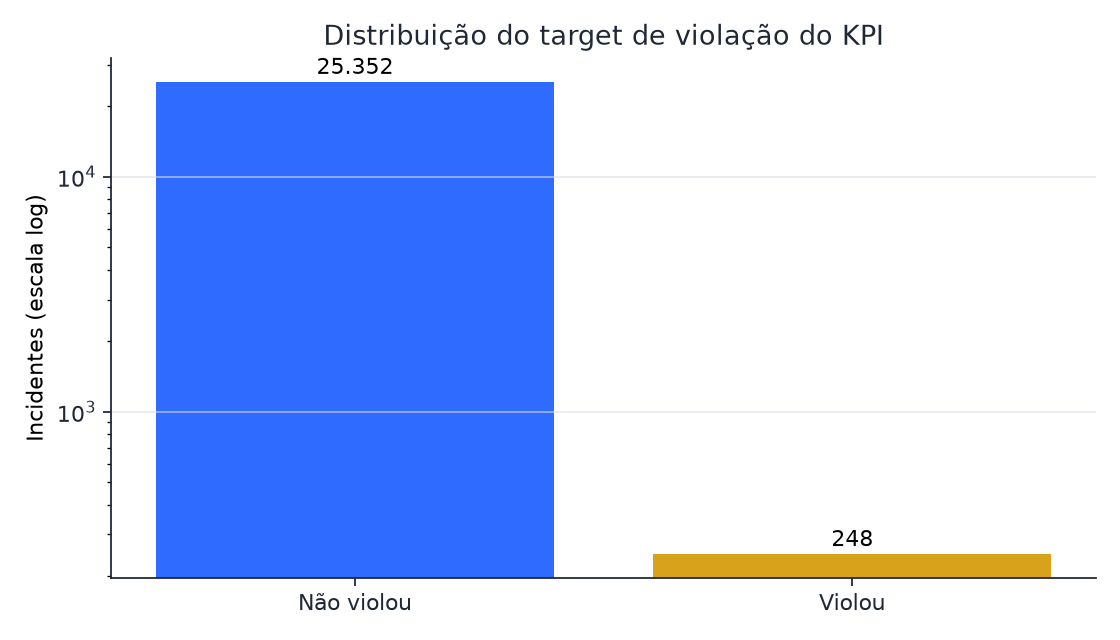

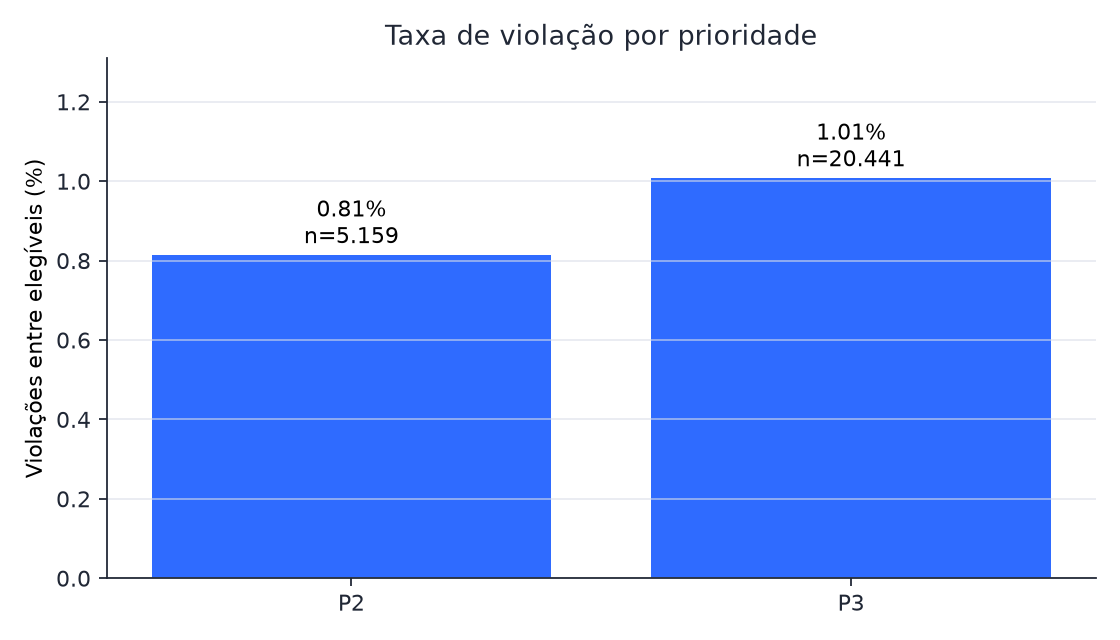

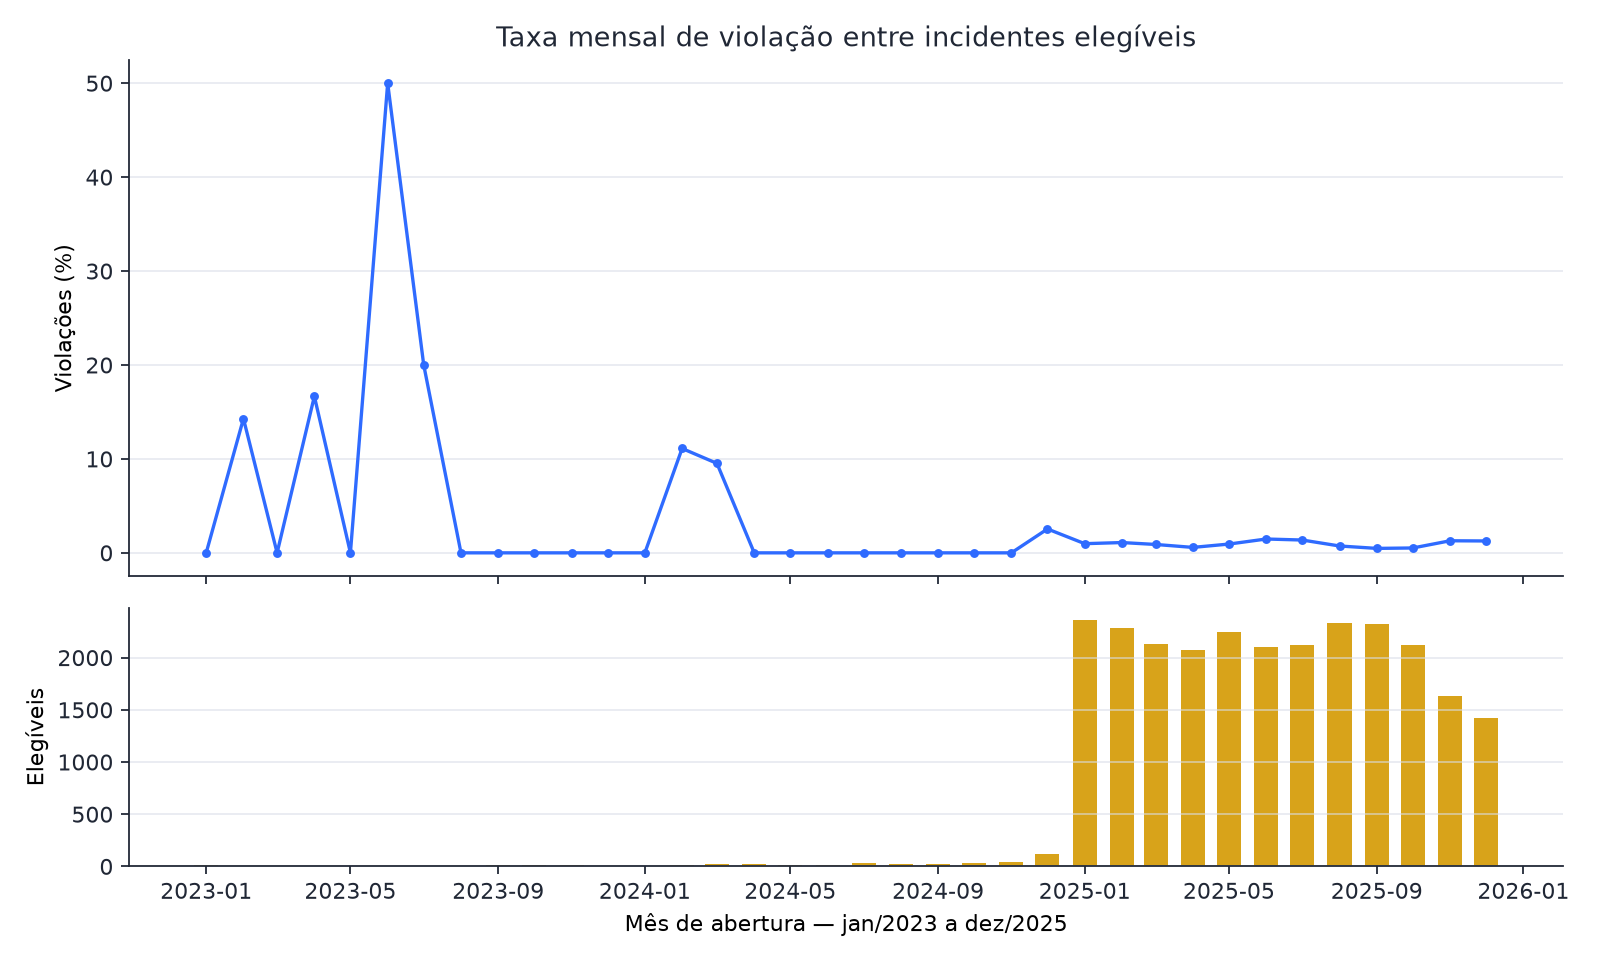

In [4]:
display(Image(filename=PROJECT_ROOT / 'artifacts/eda/risk/target_distribution.png'))
display(Image(filename=PROJECT_ROOT / 'artifacts/eda/risk/breach_rate_by_priority.png'))
display(Image(filename=PROJECT_ROOT / 'artifacts/eda/risk/monthly_breach_rate.png'))

## Data leakage

As colunas abaixo são bloqueadas pelo código. `closed_at` é consultado somente como relógio de disponibilidade de desfechos históricos; seu valor nunca entra na matriz de predictors do incidente corrente.

In [5]:
pd.DataFrame({'coluna_proibida': LEAKAGE_COLUMNS})

,coluna_proibida
0,resolved_at
1,closed_at
2,duration_seconds
3,duration_hours
4,calculated_duration_seconds
5,duration_difference_seconds
6,duration_mismatch
7,closure_code
8,solution_type
9,status


## Feature engineering

In [6]:
pd.DataFrame({'feature_permitida': MODEL_FEATURES})

,feature_permitida
0,priority_code
1,product
2,category
3,subcategory
4,assigned_group
5,configuration_item
6,opened_by
7,opened_hour
8,opened_day_of_week
9,opened_month


In [7]:
risk_features.loc[
    risk_features['entered_kpi_source'].eq(True),
    ['incident_id', 'opened_at', *MODEL_FEATURES, 'kpi_breached_source']
].head(5)

,incident_id,opened_at,priority_code,product,category,subcategory,assigned_group,configuration_item,opened_by,opened_hour,...,assigned_group_incidents_previous_1d,assigned_group_incidents_previous_7d,assigned_group_incidents_previous_30d,assigned_group_known_outcomes_previous_30d,assigned_group_breaches_previous_30d,assigned_group_breach_rate_previous_30d,product_incidents_previous_7d,category_incidents_previous_7d,priority_incidents_previous_7d,kpi_breached_source
0,INC7227672,2023-01-02 20:19:58,3,lcem,cat76,sub392,Team06,IC00604,Manual,20,...,0,0,0,0,0,NaN,0,0,0,False
1,INC7236724,2023-01-09 21:23:05,3,lvps,cat139,sub290,Team14,IC09322,Manual,21,...,0,0,0,0,0,NaN,0,0,0,False
2,INC7239171,2023-01-11 15:25:46,3,lhco,cat85,sub225,Team11,IC02690,Manual,15,...,0,0,0,0,0,NaN,0,0,1,False
3,INC7239203,2023-01-11 15:54:26,3,lcem,cat76,sub392,Team06,IC00604,Manual,15,...,0,0,1,0,0,NaN,0,0,2,False
4,INC7245297,2023-01-16 16:50:07,3,lrdo,cat112,sub221,Team11,IC02001,Manual,16,...,0,1,1,0,0,NaN,0,0,3,False


## Split temporal e pré-processamento

In [8]:
pd.DataFrame(metrics['splits']).T

,rows,positives,positive_rate,opened_at_min,opened_at_max
train,15360,165,0.010742,2023-01-02T20:19:58,2025-07-26T11:08:59
validation,5120,33,0.006445,2025-07-26T11:12:55,2025-10-01T19:09:51
test,5120,50,0.009766,2025-10-01T19:09:54,2025-12-31T18:06:15


In [9]:
pd.Series(metrics['preprocessing'], name='valor').to_frame()

,valor
input_features,"[priority_code, product, category, subcategory..."
transformed_dimension,377


## Clusterização

In [10]:
cluster = metrics['clustering']
display(pd.DataFrame(cluster['candidates']))
pd.Series({
    'silhouette_selecionado': cluster['selected_silhouette'],
    'PR-AUC baseline': cluster['baseline_validation_pr_auc'],
    'PR-AUC baseline + cluster': cluster['baseline_with_cluster_validation_pr_auc'],
    'usar_como_feature': cluster['use_as_model_feature'],
    'conclusao': cluster['conclusion'],
}, name='resultado').to_frame()

,clusters,silhouette,breach_rates
0,2,0.172303,"{'0': 0.00707361802462667, '1': 0.017865322950..."
1,3,0.147218,"{'0': 0.0032804811372334607, '1': 0.0099403578..."
2,4,0.148089,"{'0': 0.011124845488257108, '1': 0.00269360269..."
3,5,0.112776,"{'0': 0.02967741935483871, '1': 0.007866273352..."


,resultado
silhouette_selecionado,0.172303
PR-AUC baseline,0.008778
PR-AUC baseline + cluster,0.008748
usar_como_feature,False
conclusao,Cluster não melhora o PR-AUC o suficiente para...


## Baseline interpretável

In [11]:
pd.DataFrame(metrics['baseline']).T

,threshold,pr_auc,roc_auc,brier_score,precision,recall,f1,confusion_matrix
validation,0.5,0.008778,0.635643,0.357852,0.010014,0.666667,0.019731,"{'true_negative': 2912, 'false_positive': 2175..."
test,0.5,0.008729,0.472909,0.655138,0.012147,0.92,0.023977,"{'true_negative': 1329, 'false_positive': 3741..."


## Arquitetura e parametrizações da ANN

As configurações usam Dense/ReLU, Dropout, saída Sigmoid, binary cross-entropy, Adam, class weights e EarlyStopping por PR-AUC de validação.

In [12]:
pd.DataFrame([
    {
        **candidate['config'],
        'epochs_run': candidate['epochs_run'],
        'validation_pr_auc': candidate['validation_pr_auc'],
    }
    for candidate in metrics['ann_candidates']
])

,name,hidden_units,dropout,learning_rate,batch_size,epochs,patience,epochs_run,validation_pr_auc
0,compact-64-32,"[64, 32]",0.25,0.001,256,60,7,14,0.058187
1,reference-128-64-32,"[128, 64, 32]",0.30,0.001,256,60,7,10,0.040913


In [13]:
predictor = RiskPredictor(PROJECT_ROOT / settings.model_risk_path)
predictor.model.summary()

Model: "risk_compact-64-32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        24,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,305 (102.75 KB)

 Trainable params: 26,305 (102.75 KB)

 Non-trainable params: 0 (0.00 B)

## Avaliação temporal e threshold

In [14]:
pd.DataFrame(metrics['ann']).T

,threshold,pr_auc,roc_auc,brier_score,precision,recall,f1,confusion_matrix
validation,0.00779,0.058187,0.808579,0.006318,0.017368,0.787879,0.033987,"{'true_negative': 3616, 'false_positive': 1471..."
test,0.00779,0.072555,0.860982,0.009496,0.02275,0.9,0.044379,"{'true_negative': 3137, 'false_positive': 1933..."


In [15]:
thresholds = pd.DataFrame(metrics['threshold_table'])
requested = [metrics['selected_threshold'], 0.30, 0.40, 0.50, 0.60]
rows = [thresholds.iloc[(thresholds['threshold'] - value).abs().argmin()] for value in requested]
pd.DataFrame(rows).drop_duplicates('threshold').sort_values('threshold')

,threshold,precision,recall,f1
1,0.00779,0.017368,0.787879,0.033987
69,0.30000,0.000000,0.000000,0.000000
79,0.40000,0.000000,0.000000,0.000000
89,0.50000,0.000000,0.000000,0.000000
90,0.60000,0.000000,0.000000,0.000000


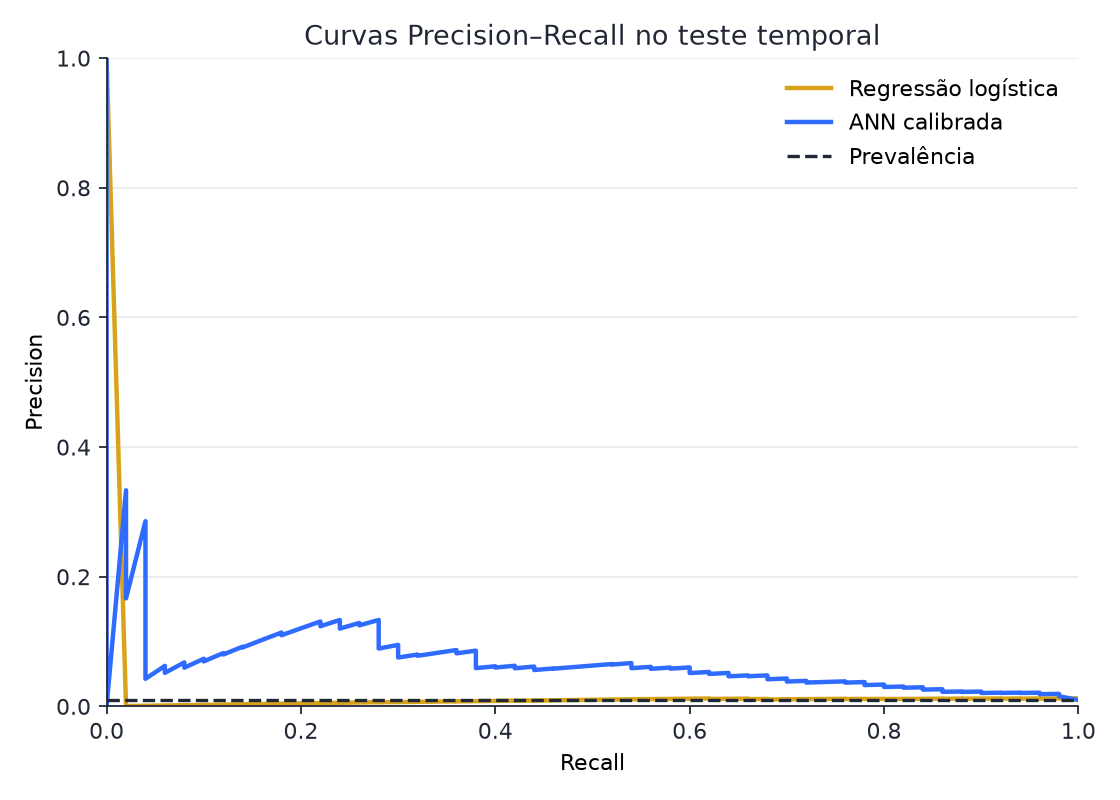

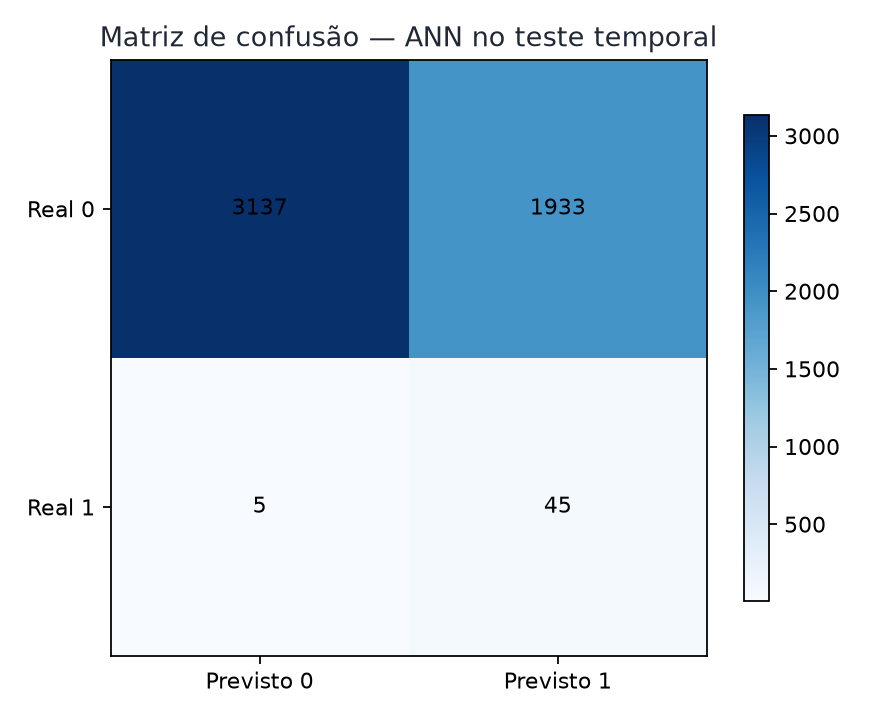

In [16]:
display(Image(filename=PROJECT_ROOT / 'artifacts/eda/risk/precision_recall_test.png'))
display(Image(filename=PROJECT_ROOT / 'artifacts/eda/risk/confusion_matrix_test.png'))

## Probabilidade, score e níveis

`breach_probability` é a probabilidade calibrada. O score operacional aplica 70% probabilidade, 20% impacto da prioridade e 10% pressão operacional. Os níveis seguem as faixas atuais do contrato e não são o mesmo que o threshold binário de classificação.

In [17]:
risk_scores[['breach_probability', 'risk_score']].describe(percentiles=[.5, .9, .95, .99])

,breach_probability,risk_score
count,5120.000000,5120.000000
mean,0.009819,19.509375
std,0.021332,4.038967
min,0.000010,12.000000
50%,0.004185,19.000000
90%,0.022147,26.000000
95%,0.030166,26.000000
99%,0.099495,26.000000
max,0.355911,37.000000


In [18]:
risk_scores['risk_level'].value_counts().rename_axis('nivel').to_frame('incidentes')

,incidentes
nivel,
baixo,4335
moderado,785


## Previsões reais e explicabilidade local

In [19]:
risk_scores.sort_values('risk_score', ascending=False).head(10)

,incident_id,scored_at,model_version,breach_probability,priority_impact,operational_pressure,risk_score,risk_level,top_risk_factors,recommended_action
5064,INC8650448,2026-08-20 20:03:22.442951+00:00,risk-ann-v1-20260820,0.355911,0.6,0.014706,37,moderado,item de configuração: IC00433; dia da semana: ...,Acompanhar evolução e capacidade da equipe res...
5051,INC8649414,2026-08-20 20:03:22.442951+00:00,risk-ann-v1-20260820,0.314069,0.6,0.058824,35,moderado,item de configuração: IC00508; volume do produ...,Acompanhar evolução e capacidade da equipe res...
4827,INC8641960,2026-08-20 20:03:22.442951+00:00,risk-ann-v1-20260820,0.166057,0.6,1.000000,34,moderado,carga da equipe nas 24h anteriores: 125; dia d...,Acompanhar evolução e capacidade da equipe res...
4995,INC8646934,2026-08-20 20:03:22.442951+00:00,risk-ann-v1-20260820,0.276905,0.6,0.029412,32,moderado,item de configuração: IC00105; categoria: cat7...,Acompanhar evolução e capacidade da equipe res...
5060,INC8649768,2026-08-20 20:03:22.442951+00:00,risk-ann-v1-20260820,0.284371,0.6,0.014706,32,moderado,item de configuração: IC00251; hora de abertur...,Acompanhar evolução e capacidade da equipe res...
4973,INC8646280,2026-08-20 20:03:22.442951+00:00,risk-ann-v1-20260820,0.241011,0.6,0.205882,31,moderado,item de configuração: IC00683; produto: lvps,Acompanhar evolução e capacidade da equipe res...
5086,INC8651433,2026-08-20 20:03:22.442951+00:00,risk-ann-v1-20260820,0.273762,0.6,0.014706,31,moderado,item de configuração: IC00251,Acompanhar evolução e capacidade da equipe res...
5014,INC8647636,2026-08-20 20:03:22.442951+00:00,risk-ann-v1-20260820,0.259835,0.6,0.014706,30,moderado,item de configuração: IC00638,Acompanhar evolução e capacidade da equipe res...
5061,INC8649800,2026-08-20 20:03:22.442951+00:00,risk-ann-v1-20260820,0.251360,0.6,0.029412,30,moderado,hora de abertura: 22; dia da semana: 5,Acompanhar evolução e capacidade da equipe res...
5033,INC8648147,2026-08-20 20:03:22.442951+00:00,risk-ann-v1-20260820,0.228545,0.6,0.102941,29,moderado,item de configuração: IC00615; categoria: cat31,Acompanhar evolução e capacidade da equipe res...


## Limitações e próximos passos

- Apenas 248 positivos existem em toda a população; intervalos de confiança e monitoramento de drift são necessários antes de produção.
- A cobertura de elegibilidade muda fortemente em 2025.
- A calibração usa somente 33 positivos de validação.
- O threshold de alto recall gera muitos falsos positivos e deve ser acordado com a capacidade da operação.
- Os clusters separam perfis operacionais, mas não melhoram o PR-AUC do baseline; por isso não entram no modelo final.
- Os níveis 0–24/25–49/50–74/75–100 são provisórios e, com probabilidades calibradas baixas, não produziram níveis alto/crítico no teste atual.

## Takeaways

A ANN fornece ranking substancialmente melhor que o baseline, mas o produto deve usar o score como priorização e não como decisão automática. O próximo passo é validar custo de alertas, acompanhar drift e recalibrar threshold/faixas com a operação.